# Практична робота 11


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завдання 1

In [2]:
data = {
    "Команда":["Dynamo", "Shakhtar", "Zorya", "Vorskla", "Desna", "Oleksandriya", "Kolos"],
    "Очки":[45, 42, 38, 35, 31, 29, 25],
    "Регіон":["Центр", "Схід", "Схід", "Центр", "Північ", "Центр", "Центр"],
    "Бюджет":[30, 40, 10, 8, 5, 6, 4],
    "Гравці":[25, 26, 24, 23, 22, 24, 25]
}

df = pd.DataFrame(data)
df["Ціна_гравця"] = df["Бюджет"] / df["Гравці"]

print("--- Базовий аналіз ---")
print(df.head(3))
print("Типи даних:\n", df.dtypes)
print("Розмір датафрейму:", df.shape)
print(df.describe())

print("\n--- Фільтрація (>30 очок) та сортування ---")
print(df[df["Очки"] > 30])
print(df.sort_values(by="Очки", ascending=False).head(3))

print("\n--- Групування та агрегація ---")
print(df.groupby("Регіон")[["Очки", "Бюджет"]].mean())
print("Максимальний бюджет по регіонах:\n", df.groupby("Регіон")["Бюджет"].max())
print("Кількість унікальних команд:", df["Команда"].nunique())

--- Базовий аналіз ---
    Команда  Очки Регіон  Бюджет  Гравці  Ціна_гравця
0    Dynamo    45  Центр      30      25     1.200000
1  Shakhtar    42   Схід      40      26     1.538462
2     Zorya    38   Схід      10      24     0.416667
Типи даних:
 Команда            str
Очки             int64
Регіон             str
Бюджет           int64
Гравці           int64
Ціна_гравця    float64
dtype: object
Розмір датафрейму: (7, 6)
            Очки     Бюджет     Гравці  Ціна_гравця
count   7.000000   7.000000   7.000000     7.000000
mean   35.000000  14.714286  24.142857     0.591461
std     7.187953  14.291189   1.345185     0.546569
min    25.000000   4.000000  22.000000     0.160000
25%    30.000000   5.500000  23.500000     0.238636
50%    35.000000   8.000000  24.000000     0.347826
75%    40.000000  20.000000  25.000000     0.808333
max    45.000000  40.000000  26.000000     1.538462

--- Фільтрація (>30 очок) та сортування ---
    Команда  Очки  Регіон  Бюджет  Гравці  Ціна_гравця
0 

# Завдання 2

            Rachel / Papineau  Berri1  Maisonneuve_1  Maisonneuve_2  Brébeuf  \
Date                                                                           
2014-01-01                 21       9             22             28        0   
2014-01-02                 43       9             18             41        0   

            Parc  PierDup  CSC (Côte Sainte-Catherine)  Pont_Jacques_Cartier  \
Date                                                                           
2014-01-01    14        3                            0                   NaN   
2014-01-02    14        0                            0                   NaN   

            Totem_Laurier  Notre-Dame  Rachel / Hôtel de Ville  Saint-Antoine  \
Date                                                                            
2014-01-01             77           6                        8              0   
2014-01-02            115           2                       18              0   

            René-Lévesque  Viger 

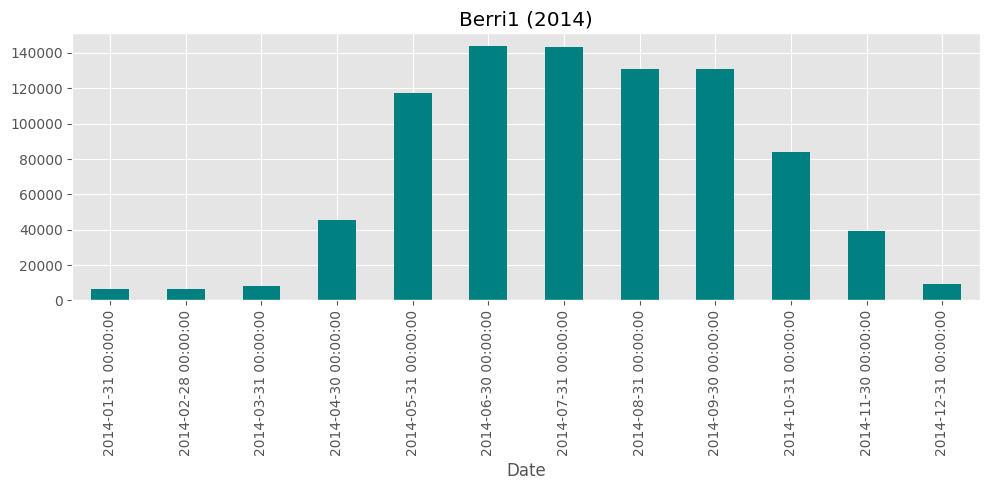

In [3]:
plt.style.use('ggplot')

df = pd.read_csv('./comptagevelo2014.csv', parse_dates=['Date'], index_col='Date')

print(df.head(2))
print(df.info())
print(df.describe())

print("\nЗагальна кількість на всіх доріжках:", df.sum(numeric_only=True).sum())
print("\nКількість по кожній доріжці:\n", df.sum(numeric_only=True))

df_monthly = df.resample('ME').sum(numeric_only=True)
paths =['Rachel / Papineau', 'Berri1', 'Maisonneuve_1']

print("\nНайпопулярніший місяць:")
for p in paths:
    if p in df_monthly.columns:
        print(f"{p}: {df_monthly[p].idxmax().month}")

if 'Berri1' in df_monthly.columns:
    df_monthly['Berri1'].plot(kind='bar', color='teal', figsize=(10, 5))
    plt.title('Berri1 (2014)')
    plt.tight_layout()
    plt.savefig('task2_plot.png')
    plt.show()

# Завдання 3

Загальна кількість слів: 23140
Топ-10 (до фільтрації): [(',', 1962), ('.', 1235), ('the', 650), ("'", 637), ('and', 546), (':', 477), ('to', 384), ('i', 348), ('of', 338), ('?', 241)]


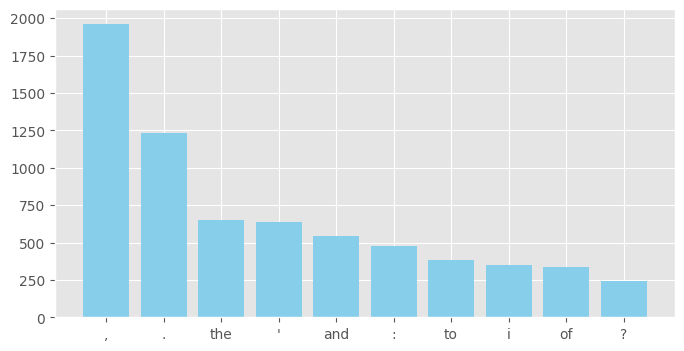

Топ-10 (після фільтрації): [('macb', 137), ('haue', 122), ('thou', 90), ('enter', 81), ('shall', 68), ('macbeth', 62), ('vpon', 62), ('thee', 61), ('macd', 58), ('vs', 57)]


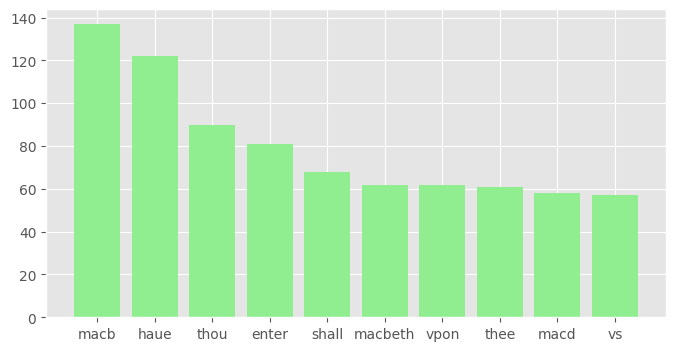

In [4]:
import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.probability import FreqDist
import string

nltk.download('gutenberg', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

words = gutenberg.words('shakespeare-macbeth.txt')
print("Загальна кількість слів:", len(words))

words_lower =[w.lower() for w in words]
top_10_raw = FreqDist(words_lower).most_common(10)
print("Топ-10 (до фільтрації):", top_10_raw)

w_raw, c_raw = zip(*top_10_raw)
plt.figure(figsize=(8, 4))
plt.bar(w_raw, c_raw, color='skyblue')
plt.savefig('task3_plot1.png')
plt.show()

stop_w = set(stopwords.words('english'))
punct = set(string.punctuation)

filtered =[w.lower() for w in words if w.lower() not in stop_w and w.lower() not in punct and w.isalpha()]
top_10_clean = FreqDist(filtered).most_common(10)
print("Топ-10 (після фільтрації):", top_10_clean)

w_cl, c_cl = zip(*top_10_clean)
plt.figure(figsize=(8, 4))
plt.bar(w_cl, c_cl, color='lightgreen')
plt.savefig('task3_plot2.png')
plt.show()